### testing ground

In [1753]:
## import numpy as np
import pandas as pd
import networkx as nx
import numpy as np
import functions_regular as fnr
import functions_subtrees as fns
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import itertools as it
import collections
import math
importlib.reload(fnr)
importlib.reload(fns)

<module 'functions_subtrees' from '/Users/mbpr/Desktop/internship/Motif discovery/motif-discovery/src/functions_subtrees.py'>

In [1985]:
# enumerates all subtrees of a tree in H rooted at h
def enumSubtrees(H, h, sb=False):
    combos = {}
    
    if (H.node[h]['coreness'] > 1 and not H.node[h]['is_root']):
        print('h is not in 1-shell and is not a root')
        
        return
    
    T = fns.detachTree(H, h, h)
    P = nx.Graph()
    P.add_edges_from(T[0].edges())
    
    children = list(T[0][h])
    
    print('T', T[0].nodes())
    print('children', children)
    
    if (len(T[0].nodes()) == 1):
        combos[0] = {}
        
        return combos
    
    elif (sb):
        aut = fnr.findSubgraphInstances(T[0], P, False)
        tClasses = fnr.findEquivalenceClasses(aut)
        
        print('T classes before:', tClasses)
        
        # remove root from all equivalence classes in T
        for key in list(tClasses.keys()):
            if (h in tClasses[key]):
                tClasses[key].remove(h)
                
            if (len(tClasses[key]) == 1 and key != tClasses[key]):
                val = list(tClasses[key])[0]
                tClasses[val] = {val}
                tClasses[key] = {key}
                
        print('T classes after:', tClasses)
        
        reps = list(tClasses.keys())
                
        print('reps:', reps)
        print('neighbors of h', list(T[0][h]))
        
        children = []
        
        for node in reps:
            if (node in T[0][h]):
                children = children + [node] * len(tClasses[node])
            
        print('children:', children)
            
        for i in range(len(children)):
            c = collections.Counter()
            c.update(map(tuple, map(sorted, it.combinations(children, i+1))))
            
            l = list(c.keys())
            combo = []
            
            print(l)
            
            for x in l:
                x = np.array(x)
                y = np.array(x)
                
                for key in tClasses.keys():
                    if (key in T[0][h]):
                        eqList = list(tClasses[key])

                        indices = np.where(x==key)
#                         print('indices:', indices)

                        if (len(indices[0]) > 1):
                            replace = eqList[:len(indices[0])]
#                             print('replace:', replace)

                            for (ind, rep) in zip(indices[0], replace):
                                y[ind] = rep
                
                combo.append(tuple(y))
            
            combos[i+1] = combo
        
    else:
        for i in range(len(children)):
            combos[i+1] = list(it.combinations(children, i+1))
        
    return combos

T [7, 4, 10, 13, 15, 14, 17, 16]
children [7, 10, 13, 14, 16]
T classes before: {4: {4}, 7: {10, 13, 7}, 14: {16, 14}, 15: {17, 15}}
T classes after: {4: set(), 7: {10, 13, 7}, 14: {16, 14}, 15: {17, 15}}
reps: [4, 7, 14, 15]
neighbors of h [7, 10, 13, 14, 16]
children: [7, 7, 7, 14, 14]
[(7,), (14,)]
[(7, 7), (7, 14), (14, 14)]
[(7, 7, 7), (7, 7, 14), (7, 14, 14)]
[(7, 7, 7, 14), (7, 7, 14, 14)]
[(7, 7, 7, 14, 14)]


{1: [(7,), (14,)],
 2: [(10, 13), (7, 14), (16, 14)],
 3: [(10, 13, 7), (10, 13, 14), (7, 16, 14)],
 4: [(10, 13, 7, 14), (10, 13, 16, 14)],
 5: [(10, 13, 7, 16, 14)]}

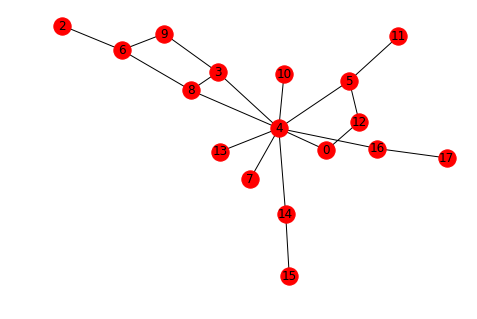

In [1988]:
G = parseStringToGraph('[[16,17], [4,16], [14,15], [4,14], [4,7], [4,10], [4,13], [12,5], [12,0], [11,5], [2,6], [3,4], [3,8], [3,9], [4,5], [4,8], [4,0], [6,8], [6,9]]')
nx.draw(G, with_labels=True)

K = nx.Graph()
K.add_edges_from(G.edges())
fns.onionDecompose(K)
fns.onionDecompose(G)

enumSubtrees(G, 4, True)

In [1716]:
L = [1,1,1,1]
c = collections.Counter()
c.update(map(tuple, map(sorted, it.combinations(L, 3))))
c

Counter({(1, 1, 1): 4})

In [1197]:
def hencealoft(H, G):
    instances = []
    
    fns.onionDecompose(G)
    fns.onionDecompose(H)
    
    marks_G = {}
    marks_H = {}
    
    K = nx.Graph()
    K.add_edges_from(H.edges())
    
    attributesH = H.nodes[1].keys()
    for name in attributesH:
        attr = nx.get_node_attributes(H, name)
        nx.set_node_attributes(K, attr, name)

    aut = fnr.findSubgraphInstances(H, K, False)
    M = fnr.symmetryConditions(aut)
    print(M)
    
    for h in H:
        
        if (H.nodes[h]['coreness'] == 1 or H.nodes[h]['is_root']):
            print('h:', h)
            combos = enumSubtrees(H, h)
            
            for i in combos:
                for select in i:
                    print('select:', select)
                    
                    T = fns.detachTree(H, h, h, select)
                    A = T[0]
                    B = T[1]
                    print('A:', A.nodes())
                    
                    for g in G:
                        if (G.nodes[g]['is_root']):
                            print('g:', g)
                            f = fnr.Map([])
                            
                            S = fns.detachTree(G, g, g)
                            S = S[0]
                            print('S:', S.nodes())
                            
                            if (len(S) >= len(A)):
                            
                                N = list(A.nodes())
                                P = list(S.nodes())
                                N.remove(h)
                                P.remove(g)
                            
                                to_extend = [(val, P[key]) for key, val in enumerate(N)]
                                to_extend.append((h, g))
                                f.extend(to_extend)

                                for s in S:
                                    if (s != g):
                                        marks_G[s] = True

                                nx.set_node_attributes(G, marks_G, 'marked')

                                count = fns.countRootedSubtrees(A, h, S, g)
                                print('count:', count)
                                f.setMult(count)

                                print('f before isoext:', f.getMap())
                                iso = fnr.isomorphicExtensions(f, H, G, 0, M)

                                for s in S:
                                    if (s != g):
                                        marks_G[s] = False

                                nx.set_node_attributes(G, marks_G, 'marked')

                                if(type(iso) == type(f)):
                                    instances.append(iso)

                                else:
                                    for i in iso:
                                        instances.append(i)
                                        print('instances:', [tuple(i.getMap()), i.getMult()])

    for g in list(G.nodes()):
        if (G.nodes[g]['coreness'] == 1):
            G.remove_node(g)
    
    print('1-shell:', [[tuple(f.getMap()), f.getMult()] for f in instances])
    
    total = 0
    for f in instances:
        total = total + f.getMult()
    
    print('1-shell:', total)
    print('2-core:', fnr.findSubgraphInstances(H, G))
    
    return total + fnr.findSubgraphInstances(H, G)
    

## flip loops

In [1851]:
def hencealoft_flipped(strH, strG):
    instances = []
    
    H = nx.Graph()
    G = nx.Graph()
    H = parseStringToGraph(strH)
    G = parseStringToGraph(strG)
    
    H.remove_edges_from(H.selfloop_edges())
    G.remove_edges_from(G.selfloop_edges())
    
    fns.onionDecompose(G)
    fns.onionDecompose(H)
    
    marks_G = {}
    marks_H = {}
    
    K = nx.Graph()
    K.add_edges_from(H.edges())
    
    attributesH = H.nodes[0].keys()
    for name in attributesH:
        attr = nx.get_node_attributes(H, name)
        nx.set_node_attributes(K, attr, name)

    aut = fnr.findSubgraphInstances(H, K, False)
    M = fnr.symmetryConditions(aut)
    print(M)
    
    combos = {}
    
    for h in H:
        if (H.nodes[h]['coreness'] == 1 or H.nodes[h]['is_root']):
            combos[h] = enumSubtrees(H, h, True)
            
            
    for g in list(G.nodes()):
        if (G.nodes[g]['is_root']):
            print('g:', g)

            S = fns.detachTree(G, g, g)
            S = S[0]
            print('S:', S.nodes())

            for h in H:
                if (H.nodes[h]['coreness'] == 1 or H.nodes[h]['is_root']):
                    print('h:', h)
                    combo = combos[h]
                    print('combo:', combo)

                    for i in combo.values():
                        for select in i:
                            print('select:', select)

                            T = fns.detachTree(H, h, h, select)
                            A = T[0]
                            B = T[1]
                            print('A:', A.nodes())

                            f = fnr.Map([(h, g)])

                            if (len(S) >= len(A)):
#                                 N = list(A.nodes())
#                                 P = list(S.nodes())
#                                 N.remove(h)
#                                 P.remove(g)

#                                 to_extend = [(val, P[key]) for key, val in enumerate(N)]
#                                 to_extend.append((h, g))
#                                 f.extend(to_extend)

                                count = fns.countRootedSubtrees(A, h, S, g)
                                print('count:', count)
                                f.setMult(count)

                                if (count > 0):

                                    for s in S:
                                        if (s != g):
                                            marks_G[s] = True
                                            print(s, 'marked')

                                    nx.set_node_attributes(G, marks_G, 'marked')

                                    print('f before isoext:', f.getMap())
                                    iso = fnr.isomorphicExtensions(f, B, G, 0, M)

                                    for s in S:
                                        if (s != g):
                                            marks_G[s] = False
                                            print(s, 'unmarked')

                                    nx.set_node_attributes(G, marks_G, 'marked')

                                    if(type(iso) == type(f)):
                                        instances.append(iso)

                                    else:
                                        for i in iso:
                                            instances.append(i)

                                    print('instances:', [[tuple(x.getMap()), x.getMult()] for x in iso])

#                 P = list(S.nodes())
#                 P.remove(g)

#                 for s in P:
#                     G.remove_node(s)

    for g in list(G.nodes()):
        if (G.nodes[g]['coreness'] == 1):
            G.remove_node(g)
    
    print('1-shell:', [[tuple(f.getMap()), f.getMult()] for f in instances])
    
    total = 0
    for f in instances:
        total = total + f.getMult()
        
    two_core = fnr.findSubgraphInstances(H, G, True)
    
    print('1-shell:', total)
    print('2-core:', two_core)
    
    return total + two_core
    

In [ ]:
H = parseStringToGraph('[[0,1], [0,2], [1,2], [0,3]]')
G = parseStringToGraph('[[1,2], [1,4], [1,6], [1,7], [2,6], [3,4], [3,8], [3,9], [4,5], [4,6], [4,8], [5,6], [5,0], [6,8], [6,9]]')

print('regular:', fnr.findSubgraphInstances(H, G, True))

H = parseStringToGraph('[[0,1], [0,2], [1,2], [0,3]]')
G = parseStringToGraph('[[1,2], [1,4], [1,6], [1,7], [2,6], [3,4], [3,8], [3,9], [4,5], [4,6], [4,8], [5,6], [5,0], [6,8], [6,9]]')
G = fns.relabelByDegree(G)

hencealoft_flipped(H, G)

In [ ]:
nx.draw(H, with_labels=True)

In [ ]:
G = parseStringToGraph('[[1,2], [1,4], [1,6], [1,7], [2,6], [3,4], [3,8], [3,9], [4,5], [4,6], [4,8], [5,6], [5,0], [6,8], [6,9]]')
G = fns.relabelByDegree(G)
nx.draw(G, with_labels=True)

In [1844]:
# H = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')
# G = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')
m = 3  #3, 4
gSize = 12
hSize = 6

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)
J = nx.Graph()
stringH = graphToString(H)
J = parseStringToGraph(stringH)
J.remove_edges_from(J.selfloop_edges())

G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
stringG = graphToString(G)
K = parseStringToGraph(stringG)
K.remove_edges_from(K.selfloop_edges())
K.remove_node(10)

print('regular:', fnr.findSubgraphInstances(J, K, True))

[((0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 6)), ((0, 5), (1, 1), (2, 6), (3, 0), (4, 3), (5, 4)), ((0, 1), (1, 5), (2, 2), (3, 8), (4, 9), (5, 11)), ((0, 1), (1, 5), (2, 6), (3, 8), (4, 9), (5, 11))]
regular: 4


In [1932]:
G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)

stringG = graphToString(G)
stringH = graphToString(H)

hencealoft_flipped(stringH, stringG)

{0: {2}, 3: {4, 5}, 4: {5}}
T [3, 1, 4, 5]
children [3, 4, 5]
T classes: {3: {3, 4, 5}}
reps: [3]
children: [3, 3, 3]
[(3,)]
[(3, 3)]
[(3, 3, 3)]
T [3]
children []


TypeError: 'int' object is not subscriptable

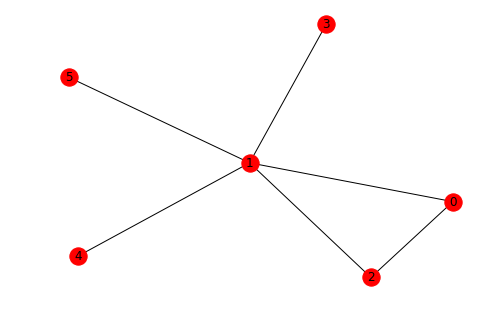

In [1584]:
nx.draw(H, with_labels=True)

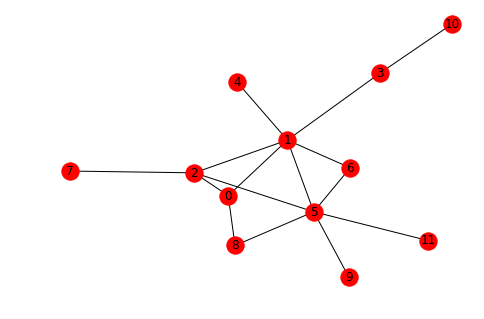

In [1628]:
G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
stringG = graphToString(G)
K = parseStringToGraph(stringG)

nx.draw(K, with_labels=True)

In [1519]:
# B = parseStringToGraph('[[3,0], [0,2], [2,4], [2,1], [0,1]]')

m = 6
gSize = 10
hSize = 5

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)
strH = graphToString(H)

F = parseStringToGraph('[[3,0], [0,2], [2,4], [2,1], [0,1]]')
T = parseStringToGraph(strH)
print(strH)
K = nx.Graph()
K.add_edges_from(H.edges())
S = nx.Graph()
S.add_edges_from(H.edges())

aut = fnr.findSubgraphInstances(F, K, False)
M = fnr.symmetryConditions(aut)
print(M)

[[0,1], [0,2], [0,3], [1,2], [2,2], [2,4]]
{0: {2}}


In [ ]:
# counts the matchings between every subtree of T with S and stores
# them in the dictionary
def countSubtreeMatchings(T, rootT, parentT, S, rootS, dic):
    dic[rootT] = fns.countRootedSubtrees(T, rootT, S, rootS)
    
    if (rootT == parentT):
        children = set(T[rootT])
    else:
        children = set(T[rootT]).difference({parentT})
    
    if (children):
        for i in children:
            Ti = fns.detachTree(T, i, rootT)
            countSubtreeMatchings(Ti, i, rootT, S, rootS, dic)
    return

T = fns.randomTree(5, 3)
S = fns.randomTree(10, 1)
dic = {}

countSubtreeMatchings(T, 4, 4, S, 9, dic)
dic

In [536]:
fns.countRootedSubtrees(T, 4, S, 14)

12.0

In [539]:
f = fnr.Map([(2, 14)])
instances = fnr.isomorphicExtensions(f, T, S, 0, M)
len([tuple(i.getMap()) for i in instances])

10

In [ ]:
from matplotlib.pyplot import figure

G = nx.scale_free_graph(50, seed=21)
G = nx.to_undirected(G)

figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
plt.axis('off')
nx.draw_networkx(G, with_labels=True, node_size=0)


In [ ]:
file = 'test_data/tests.txt'

test_findSubgraphInstances(file, 'hencealoft')

In [1015]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True
    
    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]
            
        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True
            
            
        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1
    
    return D


def test_findSubgraphInstances(file, which='regular'):
    
    D = parseFileToDict(file)
    
    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()
        
        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])
        
        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())
        
        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)
            
        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)
            
        if (which == 'hencealoft'):
            count = hencealoft_flipped(H, G)
        
        l = count
        ans = D[key]['answer']
        
        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)
        
        if(l == ans):
            print('succeeded')
        else:
            print('failed')
            
        print()
        
# convert graphs to strings
def graphToString(G):
    edges = list(G.edges())
    string = '['
    
    for edge in edges:
        to_add = '[' + str(edge[0]) + ',' + str(edge[1]) + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

In [30]:
import itertools as it

# returns a list of all subtrees of T
def enumerateSubtrees(T, node, parent, subtrees = []):
    
    if(node == parent):
        children = list(T[parent])
        root = node

    else:
        children = list(T[node]).remove(parent)

    if(children):
        for n in range(len(children) + 1):
            c = it.combinations(children, n)
            
            for t in c:  # looping through combinations
                F = nx.Graph()
                F.add_node(node)
                
                for j in t:  # looping through children in combs
                    S = fns.subtree(T, j, node)
                    S.add_edge(node, j)
                    F = nx.compose(S, F)
                    
                subtrees.append(F)
                print([i for i in F])
                
            if (n < len(children)):
                enumerateSubtrees(F, children[n], node, subtrees)

    return 


In [ ]:
T = fns.randomTree(8, 3)
S = fns.randomTree(3, 0)
nx.draw(T, with_labels=True)

In [ ]:
subtrees = []
enumerateSubtrees(T, 5, 5, subtrees)

In [ ]:
nx.draw(S, with_labels=True)

In [ ]:
T = nx.compose(T, S)
nx.draw(T, with_labels=True)